# 复现国泰海通证券：涨跌停情绪择时模型

本 Notebook 使用本地 RiceQuant 日线与 15 分钟数据，复现情绪因子的构造、有效性检验与周频择时回测。

## tl;dr

- 先检验，再回测：六个情绪因子分别对未来 1、3、5、10 个**交易日**的全 A 市值加权收益做时序统计检验。
- 有效性输出包含 Pearson/Spearman 相关、HAC 回归、方向调整后的五分位 G5-G1 价差，以及研报阈值的触发/未触发收益差。
- 研报最终择时模型使用五个因子；“涨停次日收益”只作为单因子有效性研究，不进入最终加权模型。
- 打板收益是 15 分钟数据近似，不能视为研报高频成交机制的完整复现。

In [1]:
# ============================================================
# 0. 导入、参数与因子字典
# ============================================================
import os
import sys
import time
from datetime import date, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

# 既支持在项目根目录执行 nbconvert，也支持在 Notebook 目录中交互运行。
# 不能假定 os.getcwd() 的固定层级，否则导入和输出路径会随启动方式变化。
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "my_utils").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("未找到项目根目录：上级目录中缺少 my_utils/")
NOTEBOOK_DIR = PROJECT_ROOT / "因子回测" / "涨跌停情绪因子"
for path in (str(PROJECT_ROOT), str(NOTEBOOK_DIR)):
    if path not in sys.path:
        sys.path.insert(0, path)

from my_utils.fun import get_data_trading_days, read_day_data, read_min_data
from sentiment_timing_analysis import (
    add_next_period_return,
    add_trend_buy_signal,
    analyze_factor_effectiveness,
    analyze_threshold_effectiveness,
    build_close_forward_returns,
    build_market_forward_returns,
    build_weekly_basic_factors,
)

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

START_DATE = date(2018, 1, 2)
END_DATE = date(2026, 7, 10)
DATA_SOURCE = "rq_stock_all_data"
MIN_DATA_SOURCE = "rq_15min_stock_data_dir"
OUTPUT_DIR = PROJECT_ROOT / "因子回测" / "涨跌停情绪因子" / "reproduce_output"
OUTPUT_DIR.mkdir(exist_ok=True)

# 研报阈值。该字典用于“既定规则”的条件效果检验，不用于全样本寻优。
RESEARCH_THRESHOLDS = {
    "limit_up_ratio": ("gt", 0.08),
    "limit_down_ratio": ("lt", 0.01),
    "net_limit_ratio": ("gt", 0.04),
    "limit_up_next_ret": ("gt", 0.025),
    "limit_down_next_ret": ("gt", -0.010),
    "chase_ret": ("gt", -0.005),
}

FACTOR_LABELS = {
    "limit_up_ratio": "涨停占比",
    "limit_down_ratio": "跌停占比",
    "net_limit_ratio": "净涨停占比",
    "limit_up_next_ret": "涨停次日收益",
    "limit_down_next_ret": "跌停次日收益",
    "chase_ret": "打板策略收益（15分钟近似）",
}

# 方向只用于五分位排序与方向调整 IC：G5 始终代表更强看多状态。
FACTOR_DIRECTIONS = {
    "limit_up_ratio": 1,
    "limit_down_ratio": -1,
    "net_limit_ratio": 1,
    "limit_up_next_ret": 1,
    "limit_down_next_ret": 1,
    "chase_ret": 1,
}
EFFECTIVENESS_FACTORS = list(FACTOR_LABELS)
HORIZONS = (1, 3, 5, 10)

# 研报最终模型不使用“涨停次日收益”，因此权重仅保留以下五项。
FACTOR_WEIGHTS = {
    "net_limit_ratio": 0.15,
    "limit_down_next_ret": 0.10,
    "limit_up_ratio": 0.25,
    "limit_down_ratio": 0.20,
    "chase_ret": 0.30,
}

print(f"研究区间：{START_DATE} 至 {END_DATE}")
print("主检验标的：本地全 A 正市值股票的日度市值加权收益")

研究区间：2018-01-02 至 2026-07-10
主检验标的：本地全 A 正市值股票的日度市值加权收益


---
## 1. 数据加载与质量门槛

日线只读取本研究实际使用的字段，特意不读取 `volume`，以避开历史单分区的整数/浮点 schema 差异。主研究股票池为沪深 A 股代码首位 6、0、3；涨跌停因子还会剔除 ST、停牌和无涨跌停价记录。

In [2]:
load_start = time.time()
daily_fields = [
    "code", "trading_date", "open", "high", "low", "close", "pre_close", "pct",
    "limit_up", "limit_down", "is_st", "is_suspended", "total_mv",
]
daily_raw = read_day_data(
    START_DATE, END_DATE, fields=daily_fields, file_path=DATA_SOURCE
).sort(["code", "trading_date"])

quality_gate = daily_raw.with_columns(
    pl.col("code").str.slice(5, 1).alias("code_prefix")
).select(
    [
        pl.len().alias("日线行数"),
        pl.col("code").n_unique().alias("证券数"),
        pl.col("trading_date").n_unique().alias("交易日数"),
        pl.col("trading_date").min().alias("起始日"),
        pl.col("trading_date").max().alias("截止日"),
        pl.col("code_prefix").is_in(["6", "0", "3"]).sum().alias("沪深A股行数"),
        (pl.col("total_mv").is_null() | (pl.col("total_mv") <= 0)).sum().alias("非正市值行数"),
        (pl.col("limit_up").is_null() | (pl.col("limit_up") <= 0)).sum().alias("无有效涨停价行数"),
    ]
)
print(f"加载耗时：{time.time() - load_start:.1f} 秒")
quality_gate

加载耗时：1.4 秒


日线行数,证券数,交易日数,起始日,截止日,沪深A股行数,非正市值行数,无有效涨停价行数
u32,u32,u32,date,date,u32,u32,u32
9255293,5747,2066,2018-01-02,2026-07-10,9255293,387,61703


---
## 2. 周度基础情绪因子与市场前瞻收益

基础因子由已测试的函数生成。涨跌停事件的“次日收益”严格使用全市场下一交易日，并要求该股票在下一交易日存在记录且该收益仍属于当周，从而避免周末、短周和停牌缺行导致的未来函数。

In [3]:
factor_start = time.time()
weekly_basic = build_weekly_basic_factors(daily_raw)
market_daily = build_market_forward_returns(daily_raw, horizons=HORIZONS)

# 择时回测按完整的下一自然周持有；前瞻检验则使用 1/3/5/10 个真实交易日收益。
market_weekly = (
    market_daily.with_columns(
        pl.col("trading_date").dt.strftime("%G-%V").alias("week_id")
    )
    .group_by("week_id")
    .agg(
        [
            pl.col("trading_date").max().alias("market_week_end_date"),
            ((1 + pl.col("market_daily_ret")).product() - 1).alias(
                "benchmark_value_weight_ret"
            ),
        ]
    )
)

# 周末的因子可用时点与市场收益结束日必须一致；不一致的数据不进入任何检验或回测。
weekly = (
    weekly_basic.join(market_weekly, on="week_id", how="inner")
    .join(
        market_daily.select(
            ["trading_date", *[f"future_return_{h}d" for h in HORIZONS]]
        ),
        left_on="week_end_date",
        right_on="trading_date",
        how="left",
    )
    .sort("week_end_date")
)

if weekly.filter(pl.col("week_end_date") != pl.col("market_week_end_date")).height:
    raise ValueError("周度因子结束日与市场结束日未对齐，停止后续研究")

print(f"基础因子计算耗时：{time.time() - factor_start:.1f} 秒；有效周数：{weekly.height}")
weekly.select(
    [
        "week_end_date", "trading_days_in_week", "max_daily_stock_count",
        "limit_up_count", "limit_down_count", "limit_up_ratio", "limit_down_ratio",
        "net_limit_ratio", "limit_up_next_ret", "limit_down_next_ret",
    ]
).head()

基础因子计算耗时：3.5 秒；有效周数：436


week_end_date,trading_days_in_week,max_daily_stock_count,limit_up_count,limit_down_count,limit_up_ratio,limit_down_ratio,net_limit_ratio,limit_up_next_ret,limit_down_next_ret
date,u32,u32,i64,i64,f64,f64,f64,f64,f64
2018-01-05,4,3202,154,11,0.048095,0.003435,0.04466,0.031344,-0.050515
2018-01-12,5,3208,213,6,0.066397,0.00187,0.064526,0.043913,0.041048
2018-01-19,5,3217,204,70,0.063413,0.021759,0.041654,0.03172,-0.033989
2018-01-26,5,3218,173,56,0.05376,0.017402,0.036358,0.02229,-0.024467
2018-02-02,5,3205,125,477,0.039002,0.14883,-0.109828,0.021831,-0.04761


---
## 3. 打板策略收益因子（15 分钟近似）

近似规则为：当日 15 分钟 K 线最高价首次触及昨收的 109% 时，按 109% 买入，并以**下一交易日开盘**卖出；随后固定随机种子模拟 10% 成交失败。它不能还原研报中 90 日首次触发、次日封板顺延等高频执行细节，因此会在结果中单独标注。

In [4]:
chase_start = time.time()
trading_days = get_data_trading_days(START_DATE, END_DATE)
chase_records = []
batch_size = 100

for start_idx in range(0, len(trading_days), batch_size):
    batch_days = trading_days[start_idx : start_idx + batch_size]
    if not batch_days:
        continue

    try:
        minute_data = read_min_data(
            datetime.combine(batch_days[0], datetime.min.time()),
            datetime.combine(batch_days[-1], datetime.max.time()),
            file_path=MIN_DATA_SOURCE,
        )
    except Exception as error:
        print(f"跳过 {batch_days[0]} 至 {batch_days[-1]}：15 分钟数据读取失败（{error}）")
        continue
    if minute_data.is_empty():
        continue

    day_prices = read_day_data(
        batch_days[0], batch_days[-1],
        fields=["code", "trading_date", "pre_close"], file_path=DATA_SOURCE,
    )
    if day_prices.is_empty():
        continue

    # 同一股票同日多根 K 线只形成一个事件，入场价固定为触发阈值而不是当根最高价。
    daily_events = (
        minute_data.join(day_prices, on=["code", "trading_date"], how="inner")
        .filter(pl.col("pre_close").is_finite() & (pl.col("pre_close") > 0))
        .group_by(["code", "trading_date"])
        .agg(
            [
                (pl.col("high") >= pl.col("pre_close") * 1.09).any().alias("is_triggered"),
                (pl.col("pre_close") * 1.09).first().alias("entry_price"),
            ]
        )
        .filter(pl.col("is_triggered"))
    )
    if daily_events.is_empty():
        continue

    next_date_map = {
        trading_days[index]: trading_days[index + 1]
        for index in range(start_idx, min(start_idx + len(batch_days), len(trading_days) - 1))
    }
    daily_events = daily_events.with_columns(
        pl.col("trading_date").map_elements(
            lambda value: next_date_map.get(value), return_dtype=pl.Date
        ).alias("next_trading_date")
    ).filter(pl.col("next_trading_date").is_not_null())
    if daily_events.is_empty():
        continue

    next_prices = read_day_data(
        batch_days[0],
        trading_days[min(start_idx + len(batch_days), len(trading_days) - 1)],
        fields=["code", "trading_date", "open"], file_path=DATA_SOURCE,
    ).rename({"trading_date": "next_trading_date", "open": "next_open"})
    daily_events = (
        daily_events.join(next_prices, on=["code", "next_trading_date"], how="left")
        .with_columns((pl.col("next_open") / pl.col("entry_price") - 1).alias("chase_ret"))
        .filter(pl.col("chase_ret").is_finite())
    )
    if not daily_events.is_empty():
        chase_records.append(daily_events.select(["trading_date", "chase_ret"]).to_pandas())

if chase_records:
    chase_trades = pd.concat(chase_records, ignore_index=True)
    # 设定种子使“10%成交失败”近似在重复运行时可复现。
    rng = np.random.default_rng(42)
    chase_trades = chase_trades.loc[rng.random(len(chase_trades)) >= 0.10].copy()
    chase_trades["week_id"] = pd.to_datetime(chase_trades["trading_date"]).dt.strftime("%G-%V")
    chase_weekly = pl.from_pandas(
        chase_trades.groupby("week_id", as_index=False)["chase_ret"].agg(["mean", "count"])
        .rename(columns={"mean": "chase_ret", "count": "chase_trade_count"})
    )
    print(f"近似打板交易数：{len(chase_trades):,}；有交易周数：{chase_weekly.height}")
else:
    chase_weekly = None
    print("未生成可用的近似打板交易，后续会保留该因子的空值并跳过其有效性统计。")

print(f"打板因子计算耗时：{time.time() - chase_start:.1f} 秒")

近似打板交易数：279,675；有交易周数：436
打板因子计算耗时：23.0 秒


In [5]:
# 没有事件的周不以前值或零值填充；对“事件收益”而言，缺失和收益为 0 不是同一经济含义。
if chase_weekly is not None:
    weekly = weekly.join(chase_weekly, on="week_id", how="left")
else:
    weekly = weekly.with_columns(
        [pl.lit(None, dtype=pl.Float64).alias("chase_ret"), pl.lit(0).alias("chase_trade_count")]
    )

weekly.select(
    [
        pl.len().alias("总周数"),
        pl.col("chase_ret").is_not_null().sum().alias("打板因子可用周数"),
        *[pl.col(f"future_return_{h}d").is_not_null().sum().alias(f"{h}日目标可用周数") for h in HORIZONS],
    ]
)

总周数,打板因子可用周数,1日目标可用周数,3日目标可用周数,5日目标可用周数,10日目标可用周数
u32,u32,u32,u32,u32,u32
436,436,435,435,435,434


---
## 4. 因子描述统计与阈值覆盖率

先确认因子量级与既定阈值的样本覆盖率。覆盖率过低时，阈值结果的方差会较大；这不是阈值有效性的证明。

In [6]:
factor_describe = weekly.select(EFFECTIVENESS_FACTORS).to_pandas().describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
).T
factor_describe.index = factor_describe.index.map(FACTOR_LABELS)
factor_describe

,count,mean,std,min,10%,25%,50%,75%,90%,max
涨停占比,436.0,0.06700587,0.03328174,0.00452361,0.03335910,0.04538114,0.06189867,0.08008469,0.10061890,0.24177396
跌停占比,436.0,0.02348053,0.06602996,0.00000000,0.00314432,0.00538275,0.00963864,0.01879196,0.03519092,0.86237269
净涨停占比,436.0,0.04352534,0.06524202,-0.62620424,0.01802276,0.02920770,0.04588756,0.06587762,0.08548654,0.22931507
涨停次日收益,431.0,0.01890703,0.01107326,-0.04746951,0.00647034,0.01210070,0.01888239,0.02519471,0.03241896,0.05842590
跌停次日收益,429.0,-0.02902957,0.01886207,-0.10002458,-0.05229349,-0.04088717,-0.02896898,-0.01696081,-0.00556842,0.04104847
打板策略收益（15分钟近似）,436.0,0.00342136,0.01514266,-0.03302800,-0.01018590,-0.00421954,0.00148671,0.00880646,0.01760831,0.17873113


In [7]:
threshold_coverage = []
for factor, (operator, threshold) in RESEARCH_THRESHOLDS.items():
    values = weekly.get_column(factor)
    valid_count = values.drop_nulls().len()
    if operator == "gt":
        trigger_count = weekly.filter(pl.col(factor) > threshold).height
    else:
        trigger_count = weekly.filter(pl.col(factor) < threshold).height
    threshold_coverage.append(
        {
            "因子": FACTOR_LABELS[factor],
            "规则": f"{operator} {threshold:.2%}",
            "有效样本数": valid_count,
            "触发次数": trigger_count,
            "触发率": trigger_count / valid_count if valid_count else np.nan,
        }
    )
threshold_coverage = pd.DataFrame(threshold_coverage)
threshold_coverage

,因子,规则,有效样本数,触发次数,触发率
0,涨停占比,gt 8.00%,436,109,0.25000000
1,跌停占比,lt 1.00%,436,224,0.51376147
2,净涨停占比,gt 4.00%,436,255,0.58486239
3,涨停次日收益,gt 2.50%,431,110,0.25522042
4,跌停次日收益,gt -1.00%,429,61,0.14219114
5,打板策略收益（15分钟近似）,gt -0.50%,436,337,0.77293578


---
## 5. 因子有效性检验

因子在周末形成，目标收益从该周最后一个交易日收盘后开始计。各期限使用同一可用时点：

- **Pearson / Spearman**：连续因子与前瞻市场收益的时间序列相关；
- **HAC 回归**：处理较长期限收益重叠的稳健标准误；
- **G5-G1**：按因子经济方向调整后，最强看多五分位与最弱五分位的未来收益差；
- **阈值检验**：按研报既定阈值比较触发与未触发样本，避免把覆盖率诊断误当作有效性结论。

In [8]:
effectiveness_summary, factor_group_returns = analyze_factor_effectiveness(
    weekly,
    factor_columns=EFFECTIVENESS_FACTORS,
    horizons=HORIZONS,
    factor_directions=FACTOR_DIRECTIONS,
    n_groups=5,
)
effectiveness_summary["因子"] = effectiveness_summary["factor"].map(FACTOR_LABELS)
factor_group_returns["因子"] = factor_group_returns["factor"].map(FACTOR_LABELS)

# 写出机器可读结果，供后续研究报告或样本外复核复用。
effectiveness_summary.to_csv(
    os.path.join(OUTPUT_DIR, "factor_effectiveness_summary.csv"),
    index=False, encoding="utf-8-sig",
)
factor_group_returns.to_csv(
    os.path.join(OUTPUT_DIR, "factor_group_returns.csv"),
    index=False, encoding="utf-8-sig",
)

effectiveness_summary[
    [
        "因子", "horizon", "n_obs", "pearson_ic", "spearman_ic", "hac_beta",
        "hac_t", "hac_pvalue", "directional_ic", "q5_minus_q1",
    ]
].sort_values(["因子", "horizon"])

,因子,horizon,n_obs,pearson_ic,spearman_ic,hac_beta,hac_t,hac_pvalue,directional_ic,q5_minus_q1
8,净涨停占比,1,435,0.09949431,0.08928473,0.02351710,1.60630142,0.10820770,0.09949431,0.00805193
9,净涨停占比,3,435,0.01743388,0.00620217,0.00538529,0.33927304,0.73440405,0.01743388,0.00434027
10,净涨停占比,5,435,-0.03949499,-0.03383489,-0.01649175,-0.86293507,0.38817317,-0.03949499,0.00015009
11,净涨停占比,10,434,-0.06611743,0.02194616,-0.04039807,-1.25637002,0.20898185,-0.06611743,-0.00112824
20,打板策略收益（15分钟近似）,1,435,0.29261608,0.21925439,0.29813250,4.96553909,0.00000069,0.29261608,0.01156385
21,打板策略收益（15分钟近似）,3,435,0.10192655,0.10088303,0.13571506,1.40487779,0.16005762,0.10192655,0.00932350
22,打板策略收益（15分钟近似）,5,435,0.02936274,0.07976578,0.05285022,0.55017172,0.58220160,0.02936274,0.00763286
23,打板策略收益（15分钟近似）,10,434,0.03858154,0.14885743,0.10154136,0.72513091,0.46837172,0.03858154,0.01423653
0,涨停占比,1,435,0.21451179,0.12209818,0.09939276,3.72338834,0.00019657,0.21451179,0.00834265
1,涨停占比,3,435,0.10098435,0.06663448,0.06114870,1.93509070,0.05297917,0.10098435,0.00609676


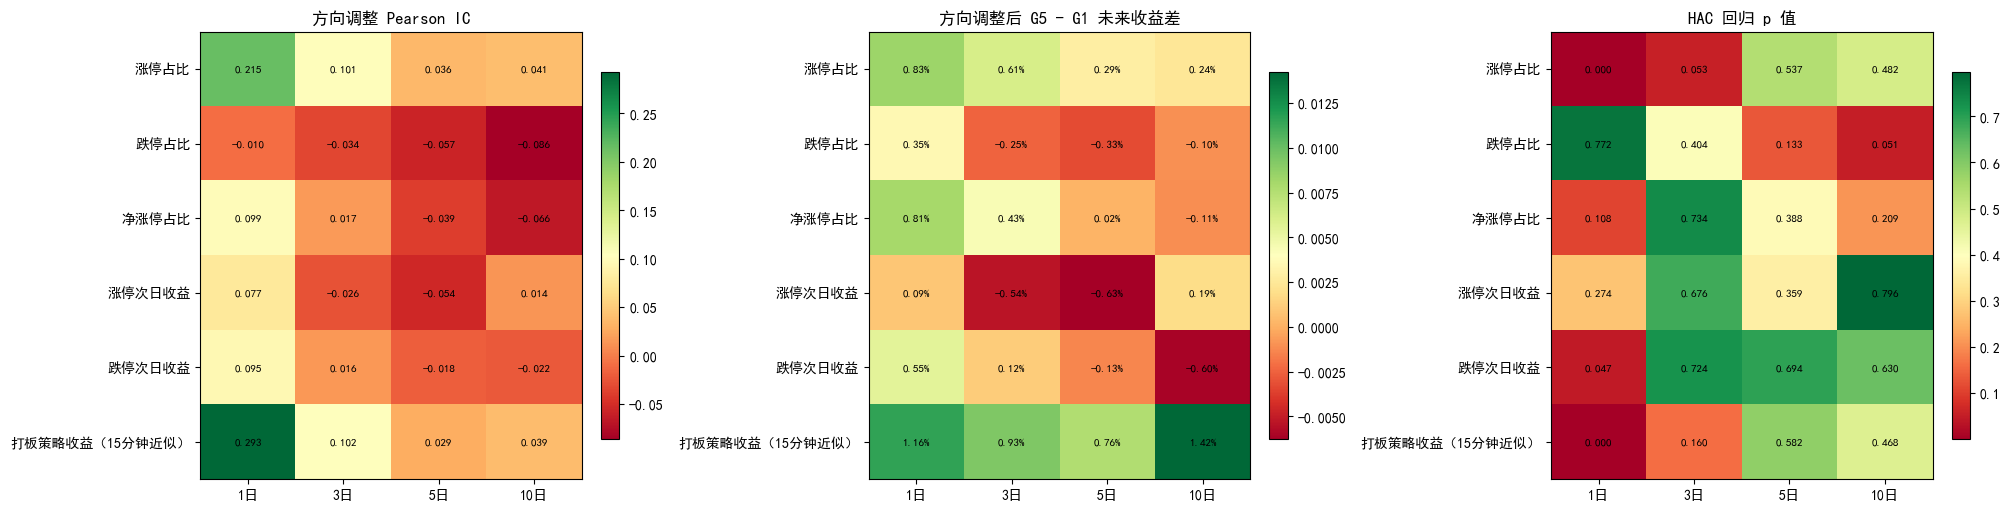

因子有效性热图已保存：C:\Users\20561\Desktop\策略\因子回测\涨跌停情绪因子\reproduce_output\factor_effectiveness_heatmaps.png


group,G1,G2,G3,G4,G5
因子,,,,,
涨停占比,0.00188144,0.00036460,-0.00288519,0.00291114,0.00474519
跌停占比,0.00421913,0.00524830,-0.00156726,-0.00181079,0.00092780
净涨停占比,0.00325334,0.00122818,0.00053541,-0.00140317,0.00340343
涨停次日收益,0.00533845,0.00411259,-0.00256838,0.00036557,-0.00093207
跌停次日收益,0.00280608,0.00110986,0.00078366,-0.00079280,0.00145862
打板策略收益（15分钟近似）,-0.00339669,0.00234987,0.00104131,0.00278654,0.00423616


In [9]:
# 图中数值均为小数收益率；HAC p 值越低，线性关系的统计证据越强。
heatmaps = [
    ("directional_ic", "方向调整 Pearson IC", ".3f"),
    ("q5_minus_q1", "方向调整后 G5 - G1 未来收益差", ".2%"),
    ("hac_pvalue", "HAC 回归 p 值", ".3f"),
]
fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
for axis, (metric, title, number_format) in zip(axes, heatmaps):
    matrix = (
        effectiveness_summary.pivot(index="因子", columns="horizon", values=metric)
        .reindex([FACTOR_LABELS[factor] for factor in EFFECTIVENESS_FACTORS])
        .reindex(columns=HORIZONS)
    )
    image = axis.imshow(matrix.to_numpy(dtype=float), aspect="auto", cmap="RdYlGn")
    axis.set_xticks(range(len(HORIZONS)), [f"{h}日" for h in HORIZONS])
    axis.set_yticks(range(len(matrix.index)), matrix.index)
    axis.set_title(title)
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix.iloc[row, column]
            label = "—" if pd.isna(value) else format(value, number_format)
            axis.text(column, row, label, ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=axis, shrink=0.82)

figure_path = os.path.join(OUTPUT_DIR, "factor_effectiveness_heatmaps.png")
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"因子有效性热图已保存：{figure_path}")

# 五分位收益表用于查看“单调性”，而不仅是看 G5-G1 的一个汇总差值。
factor_group_returns.query("horizon == 5").pivot(
    index="因子", columns="group", values="mean_return"
).reindex([FACTOR_LABELS[factor] for factor in EFFECTIVENESS_FACTORS])

---
## 6. 研报阈值的条件效果

这一节保持阈值不变，直接比较“触发”与“未触发”的未来收益、胜率和 HAC 显著性。它是样本内的条件描述，不应被解读为阈值已经完成样本外验证。

In [10]:
threshold_effectiveness = analyze_threshold_effectiveness(
    weekly, thresholds=RESEARCH_THRESHOLDS, horizons=HORIZONS
)
threshold_effectiveness["因子"] = threshold_effectiveness["factor"].map(FACTOR_LABELS)
threshold_effectiveness.to_csv(
    os.path.join(OUTPUT_DIR, "threshold_effectiveness.csv"),
    index=False, encoding="utf-8-sig",
)

threshold_effectiveness[
    [
        "因子", "horizon", "n_obs", "trigger_count", "trigger_rate",
        "trigger_mean_return", "not_trigger_mean_return", "mean_diff",
        "trigger_win_rate", "hac_pvalue",
    ]
].sort_values(["因子", "horizon"])

,因子,horizon,n_obs,trigger_count,trigger_rate,trigger_mean_return,not_trigger_mean_return,mean_diff,trigger_win_rate,hac_pvalue
8,净涨停占比,1,435,255,0.58620690,0.00320690,-0.00057961,0.00378651,0.64313725,0.01381210
9,净涨停占比,3,435,255,0.58620690,0.00260516,0.00137198,0.00123318,0.59607843,0.53839789
10,净涨停占比,5,435,255,0.58620690,0.00108747,0.00185106,-0.00076360,0.52549020,0.78011550
11,净涨停占比,10,434,254,0.58525346,0.00284269,0.00365100,-0.00080831,0.55511811,0.85933129
20,打板策略收益（15分钟近似）,1,435,337,0.77471264,0.00354939,-0.00492569,0.00847508,0.64094955,0.00005840
21,打板策略收益（15分钟近似）,3,435,337,0.77471264,0.00337459,-0.00230577,0.00568037,0.59643917,0.02586910
22,打板策略收益（15分钟近似）,5,435,337,0.77471264,0.00241919,-0.00208949,0.00450868,0.54599407,0.16486018
23,打板策略收益（15分钟近似）,10,434,336,0.77419355,0.00512431,-0.00349539,0.00861970,0.57738095,0.11694521
0,涨停占比,1,435,109,0.25057471,0.00521959,0.00044323,0.00477636,0.64220183,0.01246906
1,涨停占比,3,435,109,0.25057471,0.00577818,0.00086334,0.00491484,0.63302752,0.02991707


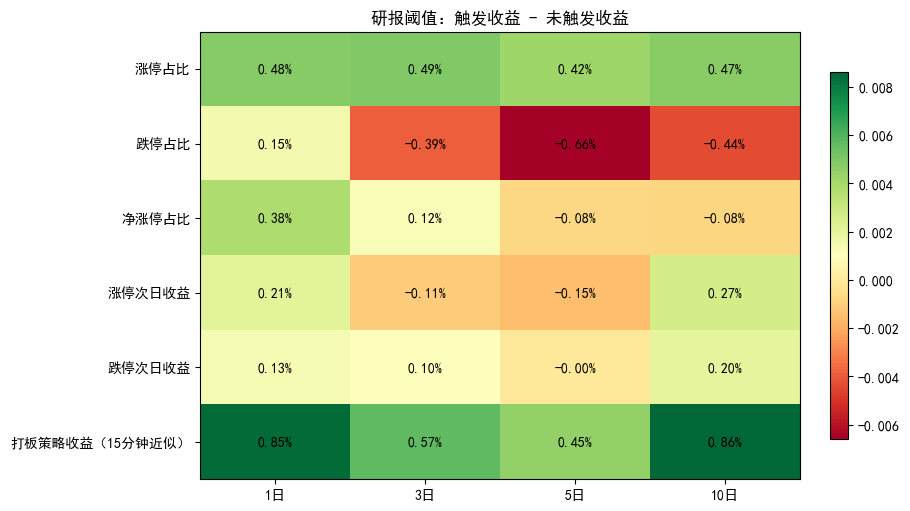

阈值有效性热图已保存：C:\Users\20561\Desktop\策略\因子回测\涨跌停情绪因子\reproduce_output\threshold_effectiveness_heatmap.png


In [11]:
threshold_matrix = (
    threshold_effectiveness.pivot(index="因子", columns="horizon", values="mean_diff")
    .reindex([FACTOR_LABELS[factor] for factor in EFFECTIVENESS_FACTORS])
    .reindex(columns=HORIZONS)
)
fig, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
image = axis.imshow(threshold_matrix.to_numpy(dtype=float), aspect="auto", cmap="RdYlGn")
axis.set_xticks(range(len(HORIZONS)), [f"{h}日" for h in HORIZONS])
axis.set_yticks(range(len(threshold_matrix.index)), threshold_matrix.index)
axis.set_title("研报阈值：触发收益 - 未触发收益")
for row in range(threshold_matrix.shape[0]):
    for column in range(threshold_matrix.shape[1]):
        value = threshold_matrix.iloc[row, column]
        axis.text(column, row, "—" if pd.isna(value) else f"{value:.2%}", ha="center", va="center")
fig.colorbar(image, ax=axis, shrink=0.82)
threshold_path = os.path.join(OUTPUT_DIR, "threshold_effectiveness_heatmap.png")
fig.savefig(threshold_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"阈值有效性热图已保存：{threshold_path}")

---
## 7. 五因子信号与周频回测

研报回测部分只使用表 9 的五个加权因子。函数集中在一个单元，避免隐藏的跨单元依赖：当前周因子形成仓位，仓位应用于**下一周**的市场收益。

In [12]:
def generate_signals(weekly_factors: pl.DataFrame, thresholds: dict) -> pl.DataFrame:
    """按既定阈值生成五个研报模型信号，并保留每个信号的可审计列。

    空值表示因子在当周不可计算，例如没有可用打板交易；该周必须产生 0 信号，
    不能用前值填充，否则会把过去信息错误带入当期。
    """
    signals = weekly_factors.clone()
    for factor in FACTOR_WEIGHTS:
        operator, threshold = thresholds[factor]
        condition = pl.col(factor) > threshold if operator == "gt" else pl.col(factor) < threshold
        signals = signals.with_columns(
            pl.when(pl.col(factor).is_not_null() & condition)
            .then(1)
            .otherwise(0)
            .alias(f"signal_{factor}")
        )
    signal_columns = [f"signal_{factor}" for factor in FACTOR_WEIGHTS]
    return signals.with_columns(sum(pl.col(column) for column in signal_columns).alias("total_signal_count"))


def compute_weighted_signal(row: dict, weights: dict) -> float:
    """使用研报既定权重汇总当周二元信号，不对样本内表现重新优化权重。"""
    return float(sum(row[f"signal_{factor}"] * weight for factor, weight in weights.items()))


def run_backtest(weekly_signals: pl.DataFrame) -> pl.DataFrame:
    """以周末可得信号决定下一周仓位，并生成基础、趋势和加权三种策略收益。"""
    result = weekly_signals.sort("week_end_date").with_columns(
        pl.when(pl.col("total_signal_count") >= 3).then(1.0)
        .when(pl.col("total_signal_count") == 2).then(0.75)
        .when(pl.col("total_signal_count") == 1).then(0.50)
        .otherwise(0.0)
        .alias("base_position")
    )
    # 周末才能完整观察到五因子；主回测统一调用共享函数，禁止在这里手写 shift，
    # 以免主回测和宽基稳健性检验再次出现一个用下周、另一个用本周的口径分裂。
    result = add_next_period_return(
        result,
        date_column="week_end_date",
        return_column="benchmark_value_weight_ret",
        output_column="next_week_ret",
    )
    # 收益年份以真正持有的下一周结束日归属，而不是以信号生成周归属；
    # 这样跨年周的收益不会被计入错误年度。
    result = add_next_period_return(
        result,
        date_column="week_end_date",
        return_column="week_end_date",
        output_column="return_week_end_date",
    )
    result = result.with_columns((pl.col("base_position") * pl.col("next_week_ret")).alias("base_model_ret"))

    signal_columns = [f"signal_{factor}" for factor in FACTOR_WEIGHTS]
    result = result.with_columns(
        pl.struct(signal_columns).map_elements(
            lambda row: compute_weighted_signal(row, FACTOR_WEIGHTS),
            return_dtype=pl.Float64,
        ).alias("weighted_signal_value")
    ).with_columns(
        pl.when(pl.col("weighted_signal_value") > 0.65).then(1.0)
        .when(pl.col("weighted_signal_value") > 0.50).then(0.80)
        .otherwise(0.0)
        .alias("weighted_position")
    ).with_columns((pl.col("weighted_position") * pl.col("next_week_ret")).alias("weighted_model_ret"))

    # 趋势增强只使用截至当周的周收益与信号，不读取下一周的收益。
    result = result.with_columns((1 + pl.col("benchmark_value_weight_ret")).cum_prod().alias("benchmark_nav"))
    for window in (10, 20, 60):
        result = result.with_columns(pl.col("benchmark_nav").rolling_mean(window).alias(f"ma_{window}"))
    result = result.with_columns(
        [
            pl.col("total_signal_count").rolling_mean(20).alias("signal_ma20"),
            pl.when((pl.col("ma_10") > pl.col("ma_20")) & (pl.col("ma_20") > pl.col("ma_60")))
            .then(pl.lit("up"))
            .when((pl.col("ma_60") > pl.col("ma_20")) & (pl.col("ma_20") > pl.col("ma_10")))
            .then(pl.lit("down"))
            .otherwise(pl.lit("sideways"))
            .alias("market_trend"),
        ]
    )
    result = add_trend_buy_signal(result)
    result = result.with_columns(
        pl.when(pl.col("trend_buy_signal")).then(1.0).otherwise(0.0).alias("trend_position")
    ).with_columns((pl.col("trend_position") * pl.col("next_week_ret")).alias("trend_model_ret"))
    # 最后一周没有后续完整持有期，只保留信号审计信息，不进入任何绩效统计。
    return result.filter(pl.col("next_week_ret").is_not_null())


def compute_perf(returns, annual_risk_free_rate: float = 0.0) -> dict:
    """以周收益计算复利年化、标准夏普、最大回撤、胜率与盈亏比。

    ``annual_risk_free_rate`` 默认为 0，方便复现无风险收益率缺失时的研究口径。
    夏普始终以周超额收益的均值/样本标准差乘 ``sqrt(52)`` 年化；它不同于
    复利年化收益率除以年化波动率，二者不能混用。
    """
    values = np.asarray(returns, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 4:
        return {"年化收益率": np.nan, "年化波动率": np.nan, "最大回撤": np.nan, "夏普比率": np.nan, "胜率": np.nan, "盈亏比": np.nan}
    annual_return = (np.prod(1 + values) ** (52 / len(values))) - 1
    annual_volatility = np.std(values, ddof=1) * np.sqrt(52)
    # 夏普以每周超额收益均值除以每周波动率后年化，不能再额外使用复利年化收益。
    weekly_risk_free_rate = (1 + annual_risk_free_rate) ** (1 / 52) - 1
    weekly_excess_returns = values - weekly_risk_free_rate
    sharpe = (
        weekly_excess_returns.mean() / weekly_excess_returns.std(ddof=1) * np.sqrt(52)
        if weekly_excess_returns.std(ddof=1) > 0
        else np.nan
    )
    nav = np.cumprod(1 + values)
    max_drawdown = ((nav / np.maximum.accumulate(nav)) - 1).min()
    wins, losses = values[values > 0], values[values < 0]
    return {
        "年化收益率": annual_return,
        "年化波动率": annual_volatility,
        "最大回撤": max_drawdown,
        "夏普比率": sharpe,
        "胜率": (values > 0).mean(),
        "盈亏比": wins.mean() / abs(losses.mean()) if len(wins) and len(losses) else np.nan,
    }


def print_perf_table(performance: dict, title: str) -> None:
    """以标准输出展示策略指标，兼容 Jupyter、nbconvert 与纯 Python 脚本。"""
    table = pd.DataFrame(performance).T
    print(title)
    formatted = table.copy()
    for column in ["年化收益率", "年化波动率", "最大回撤", "胜率"]:
        formatted[column] = formatted[column].map(
            lambda value: "—" if pd.isna(value) else f"{value:.2%}"
        )
    for column in ["夏普比率", "盈亏比"]:
        formatted[column] = formatted[column].map(
            lambda value: "—" if pd.isna(value) else f"{value:.2f}"
        )
    print(formatted.to_string())

In [13]:
signals = generate_signals(weekly, thresholds=RESEARCH_THRESHOLDS)
results = run_backtest(signals)

performance = {
    "全A市值加权基准": compute_perf(results["next_week_ret"].to_numpy()),
    "基础择时": compute_perf(results["base_model_ret"].to_numpy()),
    "市场趋势增强": compute_perf(results["trend_model_ret"].to_numpy()),
    "因子加权": compute_perf(results["weighted_model_ret"].to_numpy()),
}
print_perf_table(performance, "五因子周频回测（下一周收益口径）")

annual_returns = results.with_columns(pl.col("return_week_end_date").dt.year().alias("year")).group_by("year").agg(
    [
        ((1 + pl.col(column)).product() - 1).alias(label)
        for column, label in [
            ("next_week_ret", "全A基准"),
            ("base_model_ret", "基础择时"),
            ("trend_model_ret", "趋势增强"),
            ("weighted_model_ret", "因子加权"),
        ]
    ]
).sort("year")
annual_returns

五因子周频回测（下一周收益口径）
          年化收益率   年化波动率     最大回撤  夏普比率      胜率   盈亏比
全A市值加权基准  4.45%  18.22%  -30.99%  0.33  52.87%  1.01
基础择时      3.77%  14.79%  -30.34%  0.32  46.44%  1.06
市场趋势增强    5.92%  13.58%  -24.43%  0.49  31.72%  1.15
因子加权      3.04%  11.98%  -23.12%  0.31  24.14%  1.12


year,全A基准,基础择时,趋势增强,因子加权
i32,f64,f64,f64,f64
2018,-0.278571,-0.19147,-0.100034,-0.100817
2019,0.281188,0.210706,0.244539,0.162379
2020,0.263432,0.128556,0.190657,0.022047
2021,0.07351,0.013104,0.013465,-0.096473
2022,-0.17125,-0.158521,-0.134306,-0.069037
2023,-0.037844,-0.067824,-0.089085,-0.016439
2024,0.138601,0.160359,0.134087,0.280617
2025,0.217622,0.302052,0.288388,0.111249
2026,0.038518,0.027224,0.038518,0.021445


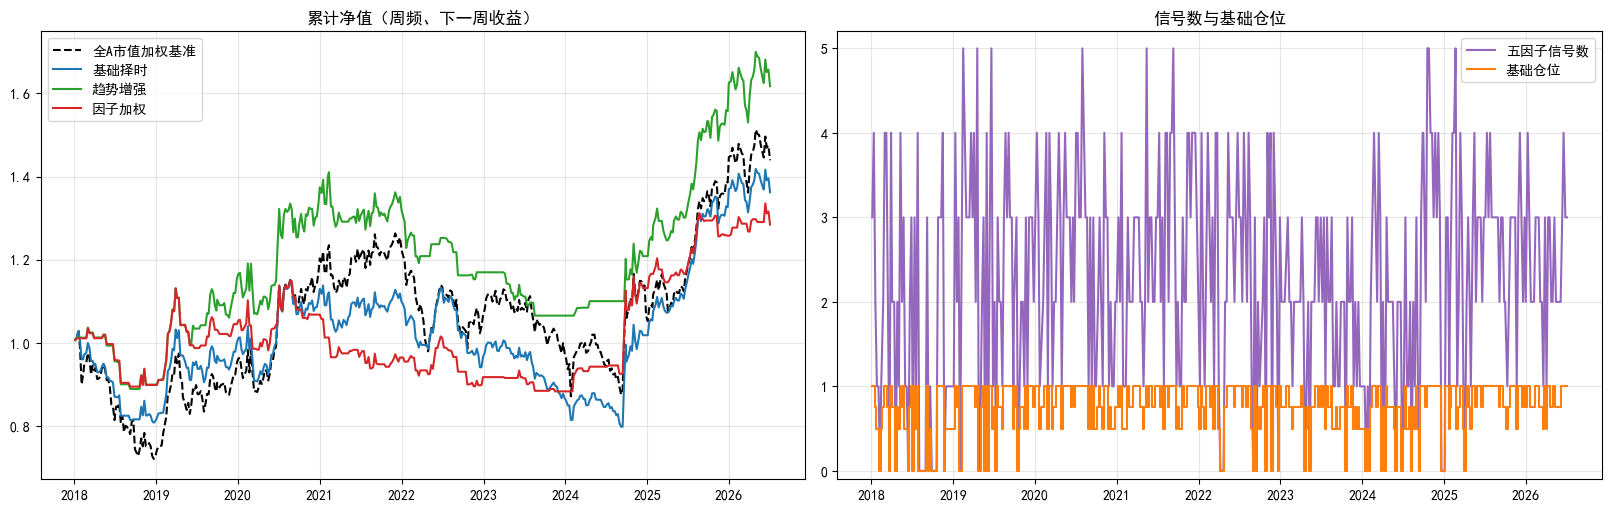

回测图及周度结果已保存至：C:\Users\20561\Desktop\策略\因子回测\涨跌停情绪因子\reproduce_output


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
for column, label, color, style in [
    ("next_week_ret", "全A市值加权基准", "black", "--"),
    ("base_model_ret", "基础择时", "#1f77b4", "-"),
    ("trend_model_ret", "趋势增强", "#2ca02c", "-"),
    ("weighted_model_ret", "因子加权", "#d62728", "-"),
]:
    axes[0].plot(results["week_end_date"], np.cumprod(1 + results[column].to_numpy()), label=label, color=color, linestyle=style)
axes[0].set_title("累计净值（周频、下一周收益）")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(results["week_end_date"], results["total_signal_count"], label="五因子信号数", color="#9467bd")
axes[1].step(results["week_end_date"], results["base_position"], label="基础仓位", color="#ff7f0e", where="mid")
axes[1].set_title("信号数与基础仓位")
axes[1].set_ylim(-0.1, 5.2)
axes[1].grid(alpha=0.3)
axes[1].legend()

backtest_path = os.path.join(OUTPUT_DIR, "timing_backtest.png")
fig.savefig(backtest_path, dpi=160, bbox_inches="tight")
plt.show()
results.write_csv(os.path.join(OUTPUT_DIR, "timing_backtest_weekly.csv"))
print(f"回测图及周度结果已保存至：{OUTPUT_DIR}")

---
## 8. 宽基指数稳健性（可选）

主检验不依赖外部 API。若本地 RiceQuant 授权可用，以下单元会将同一基础仓位应用于沪深 300、中证 500 和中证 1000 的周收益，以检查结论是否仅由全 A 股票池驱动。

In [15]:
try:
    from my_utils.rqdata import RqData

    index_client = RqData()
    index_map = {
        "000300.XSHG": "沪深300",
        "000905.XSHG": "中证500",
        "000852.XSHG": "中证1000",
    }
    robustness_performance = {}
    # 宽基价格来自独立指数行情；它们用于检验同一情绪信号在不同风格市场下的
    # 可迁移性，不替代主研究中本地全 A 市值加权代理收益。
    index_effectiveness_summaries = []
    index_factor_group_returns = []
    position_data = results.select(["week_id", "base_position"]).to_pandas()
    for index_code, index_name in index_map.items():
        index_prices = index_client.get_price(
            index_code,
            start_date=START_DATE.strftime("%Y-%m-%d"),
            end_date=END_DATE.strftime("%Y-%m-%d"),
            fields=["close"],
        )
        if index_prices is None or index_prices.empty:
            print(f"{index_name}：无可用数据，跳过")
            continue
        index_prices = index_prices.reset_index()
        date_column = "date" if "date" in index_prices.columns else "datetime"
        # 先把指数收盘价转为交易行前瞻收益。周末信号随后按 week_end_date 连接，
        # 因而 future_return_1d 指向下一交易日，而非把本周最后一天的收益重复使用。
        index_prices["trading_date"] = pd.to_datetime(index_prices[date_column]).dt.date
        index_forward_returns = build_close_forward_returns(
            pl.from_pandas(index_prices[["trading_date", "close"]]), horizons=HORIZONS
        )
        index_weekly_factors = weekly.select(["week_id", "week_end_date", *EFFECTIVENESS_FACTORS]).join(
            index_forward_returns.select(["trading_date", *[f"future_return_{h}d" for h in HORIZONS]]).rename(
                {"trading_date": "week_end_date"}
            ),
            on="week_end_date",
            how="left",
        )
        # 不另写统计公式：复用全 A 检验的 Pearson/Spearman、HAC 和方向调整分组
        # 逻辑，确保不同指数之间仅目标收益不同、统计口径完全一致。
        index_summary, index_groups = analyze_factor_effectiveness(index_weekly_factors,
            factor_columns=EFFECTIVENESS_FACTORS,
            horizons=HORIZONS,
            factor_directions=FACTOR_DIRECTIONS,
            n_groups=5,
        )
        index_summary.insert(0, "index", index_name)
        index_groups.insert(0, "index", index_name)
        index_effectiveness_summaries.append(index_summary)
        index_factor_group_returns.append(index_groups)
        # 组合稳健性回测与有效性检验分开：这里先压缩为指数周收益，再将它移到
        # 前一信号周。这样 base_position 不会赚取形成该仓位之前已知的同周行情。
        index_prices["week_id"] = pd.to_datetime(index_prices[date_column]).dt.strftime("%G-%V")
        index_prices["daily_ret"] = index_prices["close"].pct_change()
        index_weekly = index_prices.groupby("week_id", as_index=False).agg(
            week_end_date=(date_column, "max"),
            index_week_ret=("daily_ret", lambda values: (1 + values.dropna()).prod() - 1),
        )
        index_weekly = add_next_period_return(
            pl.from_pandas(index_weekly).with_columns(pl.col("week_end_date").cast(pl.Date)),
            date_column="week_end_date",
            return_column="index_week_ret",
            output_column="next_index_week_ret",
        ).to_pandas()
        comparison = position_data.merge(
            index_weekly[["week_id", "next_index_week_ret"]], on="week_id", how="inner"
        ).dropna(subset=["next_index_week_ret"])
        comparison["strategy_ret"] = comparison["base_position"] * comparison["next_index_week_ret"]
        robustness_performance[index_name] = {
            "指数基准": compute_perf(comparison["next_index_week_ret"]),
            "同仓位策略": compute_perf(comparison["strategy_ret"]),
        }
    for index_name, metrics in robustness_performance.items():
        print_perf_table(metrics, f"稳健性检验：{index_name}")
    # 分开导出摘要与分组明细，便于按指数、因子、期限复核，而不是只看单一净值图。
    if index_effectiveness_summaries:
        pd.concat(index_effectiveness_summaries, ignore_index=True).to_csv(
            os.path.join(OUTPUT_DIR, "index_effectiveness_summary.csv"), index=False, encoding="utf-8-sig"
        )
        pd.concat(index_factor_group_returns, ignore_index=True).to_csv(
            os.path.join(OUTPUT_DIR, "index_factor_group_returns.csv"), index=False, encoding="utf-8-sig"
        )
        print("宽基指数 IC、HAC 与分组收益已导出至 reproduce_output")
except Exception as error:
    print(f"宽基稳健性未运行：{error}")

e:\working\anaconda3\envs\quant\lib\site-packages\rqdatac\client.py:263: UserWarning: Your account will be expired after  34 days. Please call us at 0755-22676337 to upgrade or purchase or renew your contract.
  warnings.warn("Your account will be expired after  {} days. "


稳健性检验：沪深300
       年化收益率   年化波动率     最大回撤  夏普比率      胜率   盈亏比
指数基准   1.74%  18.49%  -45.60%  0.19  50.80%  1.04
同仓位策略  0.07%  15.16%  -45.92%  0.08  44.60%  1.04
稳健性检验：中证500
       年化收益率   年化波动率     最大回撤  夏普比率      胜率   盈亏比
指数基准   3.42%  21.66%  -41.49%  0.26  51.95%  1.02
同仓位策略  3.82%  17.31%  -38.68%  0.30  46.44%  1.05
稳健性检验：中证1000
       年化收益率   年化波动率     最大回撤  夏普比率      胜率   盈亏比
指数基准   1.60%  23.56%  -45.00%  0.18  51.72%  1.00
同仓位策略  4.05%  18.72%  -39.19%  0.30  46.67%  1.04
宽基指数 IC、HAC 与分组收益已导出至 reproduce_output


---
## 9. 结论读取与研究限制

请以第 5、6 节的实际输出判断某个因子是否有效：优先关注方向调整 IC、G5-G1、阈值收益差及 HAC p 值是否在多个期限上方向一致；不要只依据某一个期限或一张累计净值图下结论。

**必须保留的限制：**

1. 主市场收益是可从本地数据构建的全 A 市值加权代理，并非研报的 Wind 全 A；宽基指数检验用于稳健性补充。
2. 样本从 2018 年开始，未覆盖研报 2010 年以来的完整历史；所有阈值结果均为样本内描述。
3. 打板因子是 15 分钟近似，若它的可用周数、统计显著性或分组单调性较差，不应纳入最终交易规则。
4. 回测不含真实资金约束、滑点与交易成本；需要下单级验证时，应按项目 Stage 2 流程输出订单并使用 `Backtester`。

In [16]:
# 将最需要复核的统计集中展示，避免结论只挑选对模型有利的单一指标。
review_table = effectiveness_summary.assign(
    abs_hac_t=lambda frame: frame["hac_t"].abs()
)[
    ["因子", "horizon", "n_obs", "directional_ic", "q5_minus_q1", "hac_pvalue", "abs_hac_t"]
].sort_values(["hac_pvalue", "abs_hac_t"], na_position="last")
review_table.head(12)

,因子,horizon,n_obs,directional_ic,q5_minus_q1,hac_pvalue,abs_hac_t
20,打板策略收益（15分钟近似）,1,435,0.29261608,0.01156385,0.00000069,4.96553909
0,涨停占比,1,435,0.21451179,0.00834265,0.00019657,3.72338834
16,跌停次日收益,1,428,0.09518852,0.00546896,0.04656379,1.99024653
7,跌停占比,10,434,-0.08595197,-0.00103776,0.05090536,1.95227672
1,涨停占比,3,435,0.10098435,0.00609676,0.05297917,1.93509070
8,净涨停占比,1,435,0.09949431,0.00805193,0.10820770,1.60630142
6,跌停占比,5,435,-0.05712154,-0.00329133,0.13324062,1.50144453
21,打板策略收益（15分钟近似）,3,435,0.10192655,0.00932350,0.16005762,1.40487779
11,净涨停占比,10,434,-0.06611743,-0.00112824,0.20898185,1.25637002
12,涨停次日收益,1,430,0.07691856,0.00087360,0.27448455,1.09279334
